# Observed flooding in Kenya: flood type and temporal exploration

This standalone exploratory notebook inspects the rerun ADM0 observed-flood results for Kenya. It addresses three related temporal questions:

1. How do annual observed-flood metrics evolve from 2000 to 2018 for inland and coastal flooding?
2. For each annual flood footprint, how do results change when using fixed 2000 population versus contemporaneous/interpolated population?
3. For the combined 2000–2018 flood footprint (`gfd_all`), how do results change across the 2000, 2005, 2010, 2015, and 2020 population snapshots?

Inland and coastal results are kept separate throughout. In particular, concentration indices (CI) and quintile ratios (QR) are **not** combined after calculation; a valid combined-flood inequality metric would need to be calculated from the underlying distribution at an earlier analytical stage.

## 1. Imports and configuration

The GeoPackages contain one ADM0 result row each. Only their attribute tables are needed here, so they are read with Python's built-in `sqlite3` module rather than loading the country geometry.

In [69]:
from pathlib import Path
import re
import sqlite3
import warnings

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

ISO3 = "BGD"
COUNTRY_NAME = "Bangladesh"
RESULTS_RELATIVE_PATH = Path("data/results/social_flood/countries")
FLOOD_TYPES = ["inland", "coastal"]
FLOOD_TYPE_LABELS = {"inland": "Inland", "coastal": "Coastal"}
FLOOD_TYPE_COLORS = {"inland": "#2c7fb8", "coastal": "#d95f0e"}
QUINTILE_COLUMNS = [f"Q{i} Flood Risk" for i in range(1, 6)]
QUINTILE_LABELS = {f"Q{i} Flood Risk": f"Q{i}" for i in range(1, 6)}
QUINTILE_COLORS = ["#762a83", "#af8dc3", "#f7f7f7", "#7fbf7b", "#1b7837"]

In [70]:
def find_project_root(start: Path) -> Path:
    """Find the repository root whether the notebook starts in the root or notebooks/."""
    for candidate in (start, *start.parents):
        if (candidate / "data" / "results" / "social_flood").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find data/results/social_flood above the current working directory."
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_DIR = PROJECT_ROOT / RESULTS_RELATIVE_PATH / ISO3 / "inequality_metrics"

if not DATA_DIR.is_dir():
    raise FileNotFoundError(f"Expected Kenya results directory not found: {DATA_DIR}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Reading results from: {DATA_DIR}")

Project root: C:\Users\Mark.DESKTOP-UFHIN6T\Projects\flood-risk-inequality-review
Reading results from: C:\Users\Mark.DESKTOP-UFHIN6T\Projects\flood-risk-inequality-review\data\results\social_flood\countries\BGD\inequality_metrics


## 2. Reusable loading and parsing functions

The filename parser records the flood year/period, flood type, and population year/basis. Keeping this metadata in columns makes the later extension from Kenya to multiple countries relatively direct.

In [71]:
FILENAME_PATTERN = re.compile(
    r"^(?P<iso3>[A-Z]{3})_ADM0_metrics_gfd_"
    r"(?P<flood_period>all|\d{4})_"
    r"(?P<flood_type>inland|coastal)-flood_"
    r"S-(?P<socioeconomic>[^_]+)_P-(?P<population_label>.+)\.gpkg$"
)


def parse_result_filename(path: Path) -> dict:
    """Extract analysis dimensions encoded in a result filename."""
    match = FILENAME_PATTERN.match(path.name)
    if match is None:
        raise ValueError(f"Unexpected result filename: {path.name}")

    metadata = match.groupdict()
    metadata["flood_year"] = (
        pd.NA if metadata["flood_period"] == "all" else int(metadata["flood_period"])
    )
    population_year_match = re.search(r"(\d{4})$", metadata["population_label"])
    if population_year_match is None:
        raise ValueError(f"Could not parse population year from: {path.name}")
    metadata["population_year"] = int(population_year_match.group(1))
    metadata["population_basis"] = (
        "interpolated" if metadata["population_label"].startswith("interpolated-") else "snapshot"
    )
    metadata["source_file"] = path.name
    return metadata


def quote_identifier(name: str) -> str:
    """Safely quote a SQLite identifier."""
    return '"' + name.replace('"', '""') + '"'


def read_adm0_attributes(path: Path) -> dict:
    """Read the single non-spatial ADM0 result row from a GeoPackage."""
    with sqlite3.connect(path) as connection:
        layers = connection.execute(
            "SELECT table_name FROM gpkg_contents WHERE data_type = 'features'"
        ).fetchall()
        if len(layers) != 1:
            raise ValueError(f"Expected one feature layer in {path.name}; found {len(layers)}")

        layer = layers[0][0]
        columns = [
            row[1]
            for row in connection.execute(f"PRAGMA table_info({quote_identifier(layer)})")
            if row[1] not in {"fid", "geom"}
        ]
        selected_columns = ", ".join(quote_identifier(column) for column in columns)
        rows = connection.execute(
            f"SELECT {selected_columns} FROM {quote_identifier(layer)}"
        ).fetchall()

    if len(rows) != 1:
        raise ValueError(f"Expected one ADM0 row in {path.name}; found {len(rows)}")
    return dict(zip(columns, rows[0]))


def load_country_results(data_dir: Path) -> tuple[pd.DataFrame, list[str]]:
    """Load all recognized ADM0 metric GeoPackages from one country directory."""
    records = []
    skipped = []
    for path in sorted(data_dir.glob("*.gpkg")):
        try:
            metadata = parse_result_filename(path)
        except ValueError:
            skipped.append(path.name)
            continue
        records.append({**metadata, **read_adm0_attributes(path)})

    if not records:
        raise FileNotFoundError(f"No recognized result GeoPackages found in {data_dir}")

    results = pd.DataFrame.from_records(records)
    results["flood_year"] = results["flood_year"].astype("Int64")
    results["population_year"] = results["population_year"].astype(int)
    results["flood_type_label"] = results["flood_type"].map(FLOOD_TYPE_LABELS)
    results["has_exposure"] = results["Total Flood Risk"].fillna(0).gt(0)
    results["inequality_defined"] = (
        results["has_exposure"] & results[["CI", "QR"]].notna().all(axis=1)
    )
    results["quintile_sum"] = results[QUINTILE_COLUMNS].sum(axis=1)
    results["quintile_sum_difference"] = (
        results["quintile_sum"] - results["Total Flood Risk"]
    )
    return results, skipped

In [72]:
results, skipped_files = load_country_results(DATA_DIR)

print(f"Loaded {len(results)} result files for {COUNTRY_NAME}.")
if skipped_files:
    warnings.warn(f"Skipped {len(skipped_files)} unrecognized files: {skipped_files}")

display(
    results[
        [
            "flood_period", "flood_type", "population_label", "CI", "QR",
            "Population", "Population Coverage (%)", "Total Flood Risk",
        ]
    ].head()
)

Loaded 84 result files for Bangladesh.


,flood_period,flood_type,population_label,CI,QR,Population,Population Coverage (%),Total Flood Risk
0,2000,coastal,2000,NaN,NaN,"128,868,273.196",99.721,0.000
1,2000,inland,2000,-0.143,0.496,"128,868,273.196",99.721,"2,750,525.690"
2,2001,coastal,2000,NaN,NaN,"128,868,273.196",99.721,0.000
3,2001,coastal,interpolated-2001,NaN,NaN,"131,205,888.000",99.717,0.000
4,2001,inland,2000,-0.501,0.004,"128,868,273.196",99.721,"18,641.283"


## 3. Input coverage and data-quality checks

Expected Kenya coverage is:

- Annual floods: 2000–2018, two flood types, fixed-2000 and contemporaneous population. The two population cases are identical in 2000 and therefore appear as one file per flood type.
- All-years flood footprint: two flood types and five population snapshots (2000, 2005, 2010, 2015, 2020).

A zero-exposure row is allowed to have undefined CI and QR. Conversely, a positive-exposure row with a missing inequality metric is flagged.

In [73]:
annual_raw = results.loc[results["flood_period"] != "all"].copy()
all_years = results.loc[results["flood_period"] == "all"].copy()

expected_annual_years = set(range(2000, 2019))
observed_annual_years = set(annual_raw["flood_year"].dropna().astype(int))
expected_snapshot_years = {2000, 2005, 2010, 2015, 2020}
observed_snapshot_years = set(all_years["population_year"])

coverage_summary = pd.DataFrame(
    {
        "check": [
            "Total recognized files",
            "Annual files",
            "All-years files",
            "Annual year range",
            "All-years population snapshots",
            "Rows with positive exposure",
            "Rows with zero exposure",
            "Positive-exposure rows missing CI or QR",
            "Maximum absolute quintile-sum difference",
        ],
        "value": [
            len(results),
            len(annual_raw),
            len(all_years),
            f"{annual_raw['flood_year'].min()}–{annual_raw['flood_year'].max()}",
            ", ".join(map(str, sorted(observed_snapshot_years))),
            int(results["has_exposure"].sum()),
            int((~results["has_exposure"]).sum()),
            int((results["has_exposure"] & ~results["inequality_defined"]).sum()),
            results["quintile_sum_difference"].abs().max(),
        ],
    }
)
display(coverage_summary)

assert observed_annual_years == expected_annual_years, (
    f"Annual year coverage differs from expectation. Missing: "
    f"{sorted(expected_annual_years - observed_annual_years)}"
)
assert set(results["flood_type"]) == set(FLOOD_TYPES), "Unexpected flood-type coverage."
assert observed_snapshot_years == expected_snapshot_years, "Unexpected population snapshots."
assert not (results["has_exposure"] & ~results["inequality_defined"]).any(), (
    "At least one positive-exposure row has undefined CI or QR."
)
assert np.allclose(
    results["quintile_sum"], results["Total Flood Risk"], equal_nan=True, rtol=1e-9, atol=1e-6
), "Quintile exposures do not sum to total exposure."

print("Core coverage and consistency checks passed.")

,check,value
0,Total recognized files,84
1,Annual files,74
2,All-years files,10
3,Annual year range,2000–2018
4,All-years population snapshots,"2000, 2005, 2010, 2015, 2020"
5,Rows with positive exposure,55
6,Rows with zero exposure,29
7,Positive-exposure rows missing CI or QR,0
8,Maximum absolute quintile-sum difference,0.000


Core coverage and consistency checks passed.


In [74]:
status_by_type = (
    results.groupby("flood_type_label", observed=True)
    .agg(
        files=("source_file", "size"),
        positive_exposure_rows=("has_exposure", "sum"),
        total_exposure_min=("Total Flood Risk", "min"),
        total_exposure_max=("Total Flood Risk", "max"),
        population_coverage_min=("Population Coverage (%)", "min"),
        population_coverage_max=("Population Coverage (%)", "max"),
    )
)
display(status_by_type)

zero_exposure_types = status_by_type.index[
    status_by_type["positive_exposure_rows"].eq(0)
].tolist()
if zero_exposure_types:
    print(
        "Note: no positive exposure was recorded for: " + ", ".join(zero_exposure_types) + ". "
        "CI and QR are therefore undefined for those rows."
    )

,files,positive_exposure_rows,total_exposure_min,total_exposure_max,population_coverage_min,population_coverage_max
flood_type_label,,,,,,
Coastal,42,13,0.000,"8,766,546.511",99.667,99.721
Inland,42,42,"18,641.283","209,155,913.477",99.667,99.721


## 4. View A — annual flooding with contemporaneous population

This view pairs each flood year with the population surface for the same year. Population is observed at five-year intervals and interpolated for intervening years in the upstream analysis.

In [75]:
annual_current = annual_raw.loc[
    annual_raw["population_year"].eq(annual_raw["flood_year"].astype(int))
].copy()

expected_current_rows = len(expected_annual_years) * len(FLOOD_TYPES)
assert len(annual_current) == expected_current_rows, (
    f"Expected {expected_current_rows} contemporaneous annual rows; found {len(annual_current)}."
)

annual_current_summary = (
    annual_current.groupby("flood_type_label", observed=True)
    .agg(
        years=("flood_year", "nunique"),
        years_with_exposure=("has_exposure", "sum"),
        cumulative_annual_exposure=("Total Flood Risk", "sum"),
        median_positive_year_exposure=(
            "Total Flood Risk", lambda values: values[values.gt(0)].median()
        ),
        mean_CI=("CI", "mean"),
        mean_QR=("QR", "mean"),
        coverage_min=("Population Coverage (%)", "min"),
        coverage_max=("Population Coverage (%)", "max"),
    )
)
display(annual_current_summary)

,years,years_with_exposure,cumulative_annual_exposure,median_positive_year_exposure,mean_CI,mean_QR,coverage_min,coverage_max
flood_type_label,,,,,,,,
Coastal,19,4,"7,887,937.692","1,828,618.812",-0.257,0.231,99.670,99.721
Inland,19,19,"178,990,599.880","6,079,467.619",-0.379,0.156,99.670,99.721


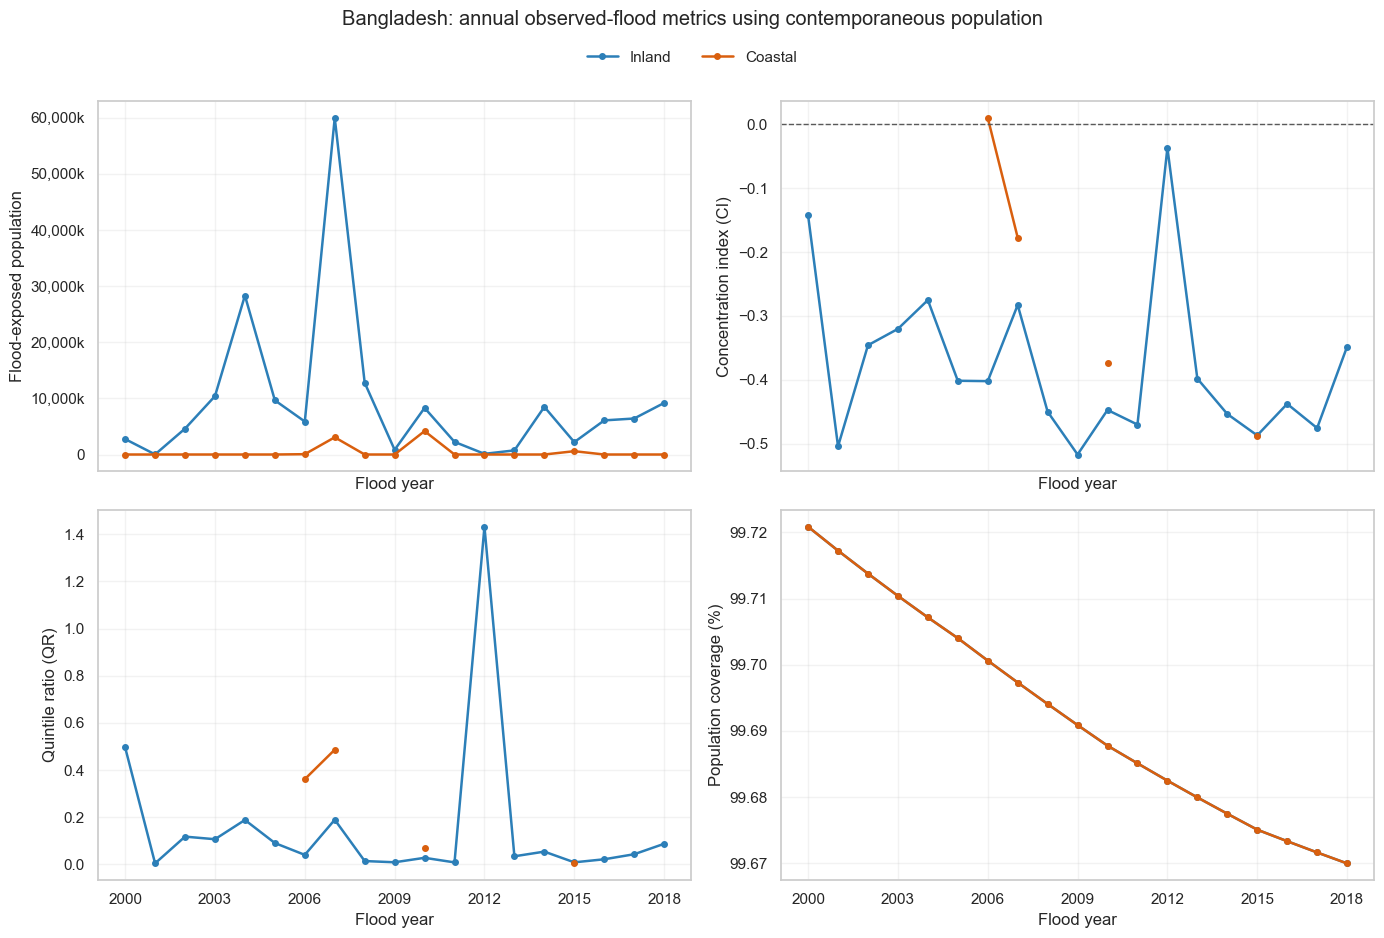

In [76]:
def thousands(value, position):
    return f"{value / 1_000:,.0f}k" if abs(value) >= 1_000 else f"{value:,.0f}"


fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
plot_specs = [
    ("Total Flood Risk", "Flood-exposed population", axes[0, 0]),
    ("CI", "Concentration index (CI)", axes[0, 1]),
    ("QR", "Quintile ratio (QR)", axes[1, 0]),
    ("Population Coverage (%)", "Population coverage (%)", axes[1, 1]),
]

for metric, ylabel, ax in plot_specs:
    for flood_type in FLOOD_TYPES:
        subset = annual_current.loc[annual_current["flood_type"].eq(flood_type)].sort_values("flood_year")
        ax.plot(
            subset["flood_year"], subset[metric], marker="o", linewidth=1.8, markersize=4,
            label=FLOOD_TYPE_LABELS[flood_type], color=FLOOD_TYPE_COLORS[flood_type],
        )
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Flood year")
    ax.set_xticks(range(2000, 2019, 3))
    if metric == "Total Flood Risk":
        ax.yaxis.set_major_formatter(FuncFormatter(thousands))
    if metric == "CI":
        ax.axhline(0, color="0.35", linewidth=1, linestyle="--")
    ax.grid(alpha=0.25)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.01))
fig.suptitle(f"{COUNTRY_NAME}: annual observed-flood metrics using contemporaneous population", y=1.04)
fig.tight_layout()
plt.show()

Interpretation reminder: negative CI indicates that flood exposure is concentrated toward relatively poorer populations, while positive CI indicates concentration toward relatively wealthier populations. QR should be interpreted alongside its precise upstream definition; here it is explored as supplied rather than recomputed.

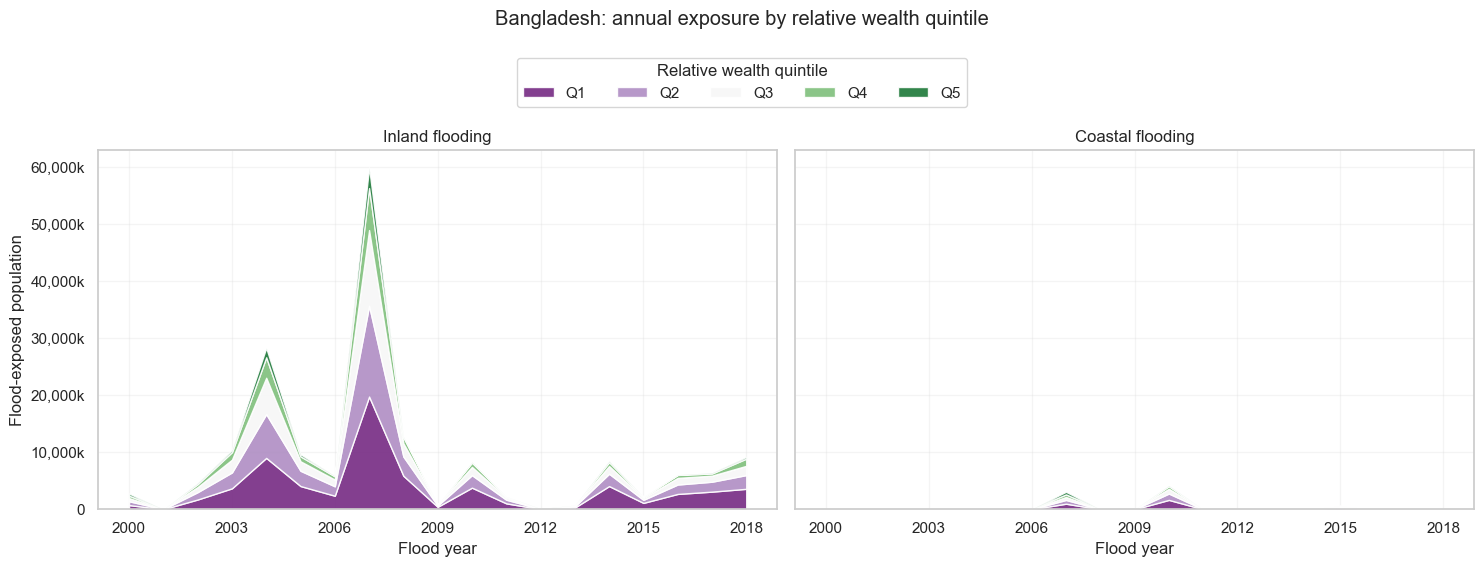

In [77]:
annual_quintiles = annual_current.melt(
    id_vars=["flood_year", "flood_type", "flood_type_label", "Total Flood Risk"],
    value_vars=QUINTILE_COLUMNS,
    var_name="wealth_quintile",
    value_name="flood_exposure",
)
annual_quintiles["wealth_quintile"] = annual_quintiles["wealth_quintile"].map(QUINTILE_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, flood_type in zip(axes, FLOOD_TYPES):
    subset = annual_quintiles.loc[annual_quintiles["flood_type"].eq(flood_type)]
    pivot = (
        subset.pivot(index="flood_year", columns="wealth_quintile", values="flood_exposure")
        .reindex(columns=[f"Q{i}" for i in range(1, 6)])
        .fillna(0)
    )
    if pivot.to_numpy().sum() > 0:
        ax.stackplot(
            pivot.index.astype(int),
            *[pivot[column] for column in pivot.columns],
            labels=pivot.columns,
            colors=QUINTILE_COLORS,
            alpha=0.9,
        )
    else:
        ax.text(0.5, 0.5, "No recorded exposure", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(f"{FLOOD_TYPE_LABELS[flood_type]} flooding")
    ax.set_xlabel("Flood year")
    ax.set_xticks(range(2000, 2019, 3))
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Flood-exposed population")
axes[0].yaxis.set_major_formatter(FuncFormatter(thousands))
if annual_quintiles["flood_exposure"].sum() > 0:
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, title="Relative wealth quintile", ncol=5, loc="upper center", bbox_to_anchor=(0.5, 1.05))
fig.suptitle(f"{COUNTRY_NAME}: annual exposure by relative wealth quintile", y=1.13)
fig.tight_layout()
plt.show()

## 5. View B — fixed 2000 versus contemporaneous population

This comparison isolates the influence of population change on each year's fixed flood footprint. The 2000 row is both the baseline and contemporaneous case, so it is labelled as the baseline and is not duplicated.

In [78]:
annual_sensitivity = annual_raw.copy()
annual_sensitivity["population_scenario"] = np.select(
    [
        annual_sensitivity["population_year"].eq(2000),
        annual_sensitivity["population_year"].eq(annual_sensitivity["flood_year"].astype(int)),
    ],
    ["Fixed 2000 population", "Contemporaneous population"],
    default="Other",
)
assert not annual_sensitivity["population_scenario"].eq("Other").any(), (
    "Unexpected annual population scenario encountered."
)

scenario_counts = annual_sensitivity.pivot_table(
    index="flood_type_label", columns="population_scenario", values="source_file", aggfunc="count", fill_value=0
)
display(scenario_counts)

population_scenario,Contemporaneous population,Fixed 2000 population
flood_type_label,,
Coastal,18,19
Inland,18,19


In [79]:
paired = annual_raw.pivot_table(
    index=["flood_year", "flood_type", "flood_type_label"],
    columns="population_year",
    values=["CI", "QR", "Population", "Population Coverage (%)", "Total Flood Risk", *QUINTILE_COLUMNS],
    aggfunc="first",
)

comparison_records = []
for (flood_year, flood_type, flood_type_label), row in paired.iterrows():
    flood_year = int(flood_year)
    if flood_year == 2000 or ("Total Flood Risk", flood_year) not in paired.columns:
        continue
    record = {
        "flood_year": flood_year,
        "flood_type": flood_type,
        "flood_type_label": flood_type_label,
    }
    for metric in ["CI", "QR", "Population", "Population Coverage (%)", "Total Flood Risk", *QUINTILE_COLUMNS]:
        baseline = row.get((metric, 2000), np.nan)
        current = row.get((metric, flood_year), np.nan)
        record[f"{metric} | fixed_2000"] = baseline
        record[f"{metric} | current"] = current
        record[f"{metric} | change"] = current - baseline
        record[f"{metric} | percent_change"] = (
            (current / baseline - 1) * 100 if pd.notna(baseline) and baseline != 0 else np.nan
        )
    comparison_records.append(record)

population_effect = pd.DataFrame(comparison_records)
display(
    population_effect[
        [
            "flood_year", "flood_type_label",
            "Total Flood Risk | fixed_2000", "Total Flood Risk | current",
            "Total Flood Risk | change", "Total Flood Risk | percent_change",
            "CI | change", "QR | change",
        ]
    ].head(10)
)

,flood_year,flood_type_label,Total Flood Risk | fixed_2000,Total Flood Risk | current,Total Flood Risk | change,Total Flood Risk | percent_change,CI | change,QR | change
0,2001,Coastal,0.000,0.000,0.000,NaN,NaN,NaN
1,2001,Inland,"18,641.283","18,815.468",174.185,0.934,-0.003,0.000
2,2002,Coastal,0.000,0.000,0.000,NaN,NaN,NaN
3,2002,Inland,"4,476,749.524","4,611,657.063","134,907.538",3.014,-0.003,0.003
4,2003,Coastal,0.000,0.000,0.000,NaN,NaN,NaN
5,2003,Inland,"9,988,733.838","10,401,849.009","413,115.171",4.136,-0.002,-0.000
6,2004,Coastal,0.000,0.000,0.000,NaN,NaN,NaN
7,2004,Inland,"26,573,490.282","28,316,153.938","1,742,663.656",6.558,-0.002,0.008
8,2005,Coastal,0.000,0.000,0.000,NaN,NaN,NaN
9,2005,Inland,"8,971,200.832","9,651,502.662","680,301.830",7.583,0.002,0.009


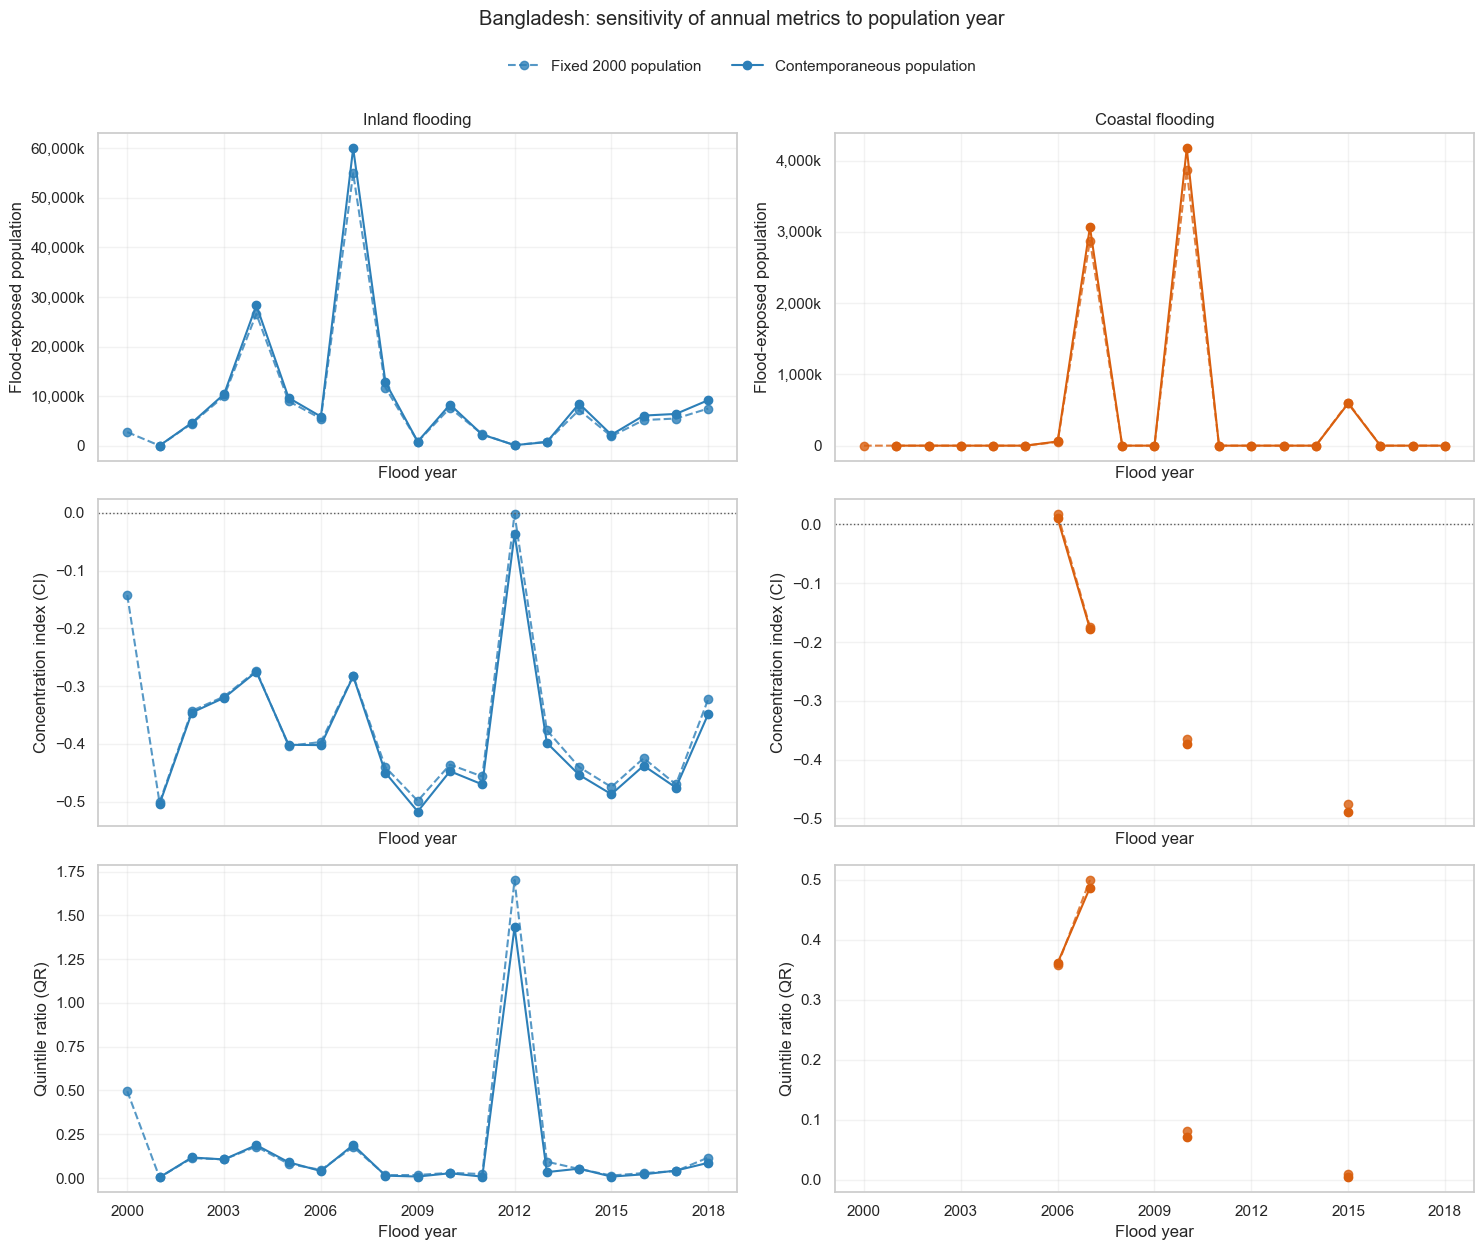

In [80]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex=True)
scenario_styles = {
    "Fixed 2000 population": {"linestyle": "--", "marker": "o", "alpha": 0.8},
    "Contemporaneous population": {"linestyle": "-", "marker": "o", "alpha": 1.0},
}
metrics = [
    ("Total Flood Risk", "Flood-exposed population"),
    ("CI", "Concentration index (CI)"),
    ("QR", "Quintile ratio (QR)"),
]

for column_index, flood_type in enumerate(FLOOD_TYPES):
    flood_subset = annual_sensitivity.loc[annual_sensitivity["flood_type"].eq(flood_type)]
    for row_index, (metric, ylabel) in enumerate(metrics):
        ax = axes[row_index, column_index]
        for scenario, style in scenario_styles.items():
            subset = flood_subset.loc[
                flood_subset["population_scenario"].eq(scenario)
            ].sort_values("flood_year")
            ax.plot(
                subset["flood_year"], subset[metric], label=scenario,
                color=FLOOD_TYPE_COLORS[flood_type], **style,
            )
        if row_index == 0:
            ax.set_title(f"{FLOOD_TYPE_LABELS[flood_type]} flooding")
            ax.yaxis.set_major_formatter(FuncFormatter(thousands))
        if metric == "CI":
            ax.axhline(0, color="0.35", linewidth=1, linestyle=":")
        ax.set_ylabel(ylabel)
        ax.set_xlabel("Flood year")
        ax.set_xticks(range(2000, 2019, 3))
        ax.grid(alpha=0.25)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.01))
fig.suptitle(f"{COUNTRY_NAME}: sensitivity of annual metrics to population year", y=1.04)
fig.tight_layout()
plt.show()

In [81]:
population_effect_summary = (
    population_effect.groupby("flood_type_label", observed=True)
    .agg(
        comparable_years=("flood_year", "count"),
        median_exposure_change=("Total Flood Risk | change", "median"),
        median_exposure_percent_change=("Total Flood Risk | percent_change", "median"),
        maximum_exposure_percent_change=("Total Flood Risk | percent_change", "max"),
        median_CI_change=("CI | change", "median"),
        maximum_absolute_CI_change=("CI | change", lambda values: values.abs().max()),
        median_QR_change=("QR | change", "median"),
        maximum_absolute_QR_change=("QR | change", lambda values: values.abs().max()),
    )
)
display(population_effect_summary)

,comparable_years,median_exposure_change,median_exposure_percent_change,maximum_exposure_percent_change,median_CI_change,maximum_absolute_CI_change,median_QR_change,maximum_absolute_QR_change
flood_type_label,,,,,,,,
Coastal,18,0.000,7.273,12.661,-0.008,0.013,-0.008,0.013
Inland,18,"544,676.432",7.399,22.528,-0.010,0.034,-0.003,0.269


## 6. View C — all observed floods across population snapshots

Here the combined 2000–2018 flood footprint is held fixed while the population surface changes at five-year intervals. This provides the cleanest view of how population redistribution and growth alter exposure and inequality for a fixed observed-flood footprint.

In [82]:
all_years = all_years.sort_values(["flood_type", "population_year"]).copy()
expected_all_rows = len(FLOOD_TYPES) * len(expected_snapshot_years)
assert len(all_years) == expected_all_rows, (
    f"Expected {expected_all_rows} all-years rows; found {len(all_years)}."
)

display(
    all_years[
        [
            "flood_type_label", "population_year", "Population",
            "Population Coverage (%)", "Total Flood Risk", "CI", "QR",
        ]
    ].sort_values(["flood_type_label", "population_year"])
)

,flood_type_label,population_year,Population,Population Coverage (%),Total Flood Risk,CI,QR
74,Coastal,2000,"128,868,273.196",99.721,"7,395,473.627",-0.297,0.217
75,Coastal,2005,"140,556,363.599",99.704,"7,802,648.773",-0.299,0.218
76,Coastal,2010,"148,017,229.729",99.688,"7,926,673.479",-0.299,0.206
77,Coastal,2015,"157,424,929.302",99.675,"8,220,055.942",-0.298,0.207
78,Coastal,2020,"166,967,975.296",99.667,"8,766,546.511",-0.295,0.212
79,Inland,2000,"128,868,273.196",99.721,"163,859,315.452",-0.337,0.116
80,Inland,2005,"140,556,363.599",99.704,"175,760,999.212",-0.336,0.123
81,Inland,2010,"148,017,229.729",99.688,"181,957,886.689",-0.335,0.126
82,Inland,2015,"157,424,929.302",99.675,"192,462,272.538",-0.333,0.133
83,Inland,2020,"166,967,975.296",99.667,"209,155,913.477",-0.330,0.138


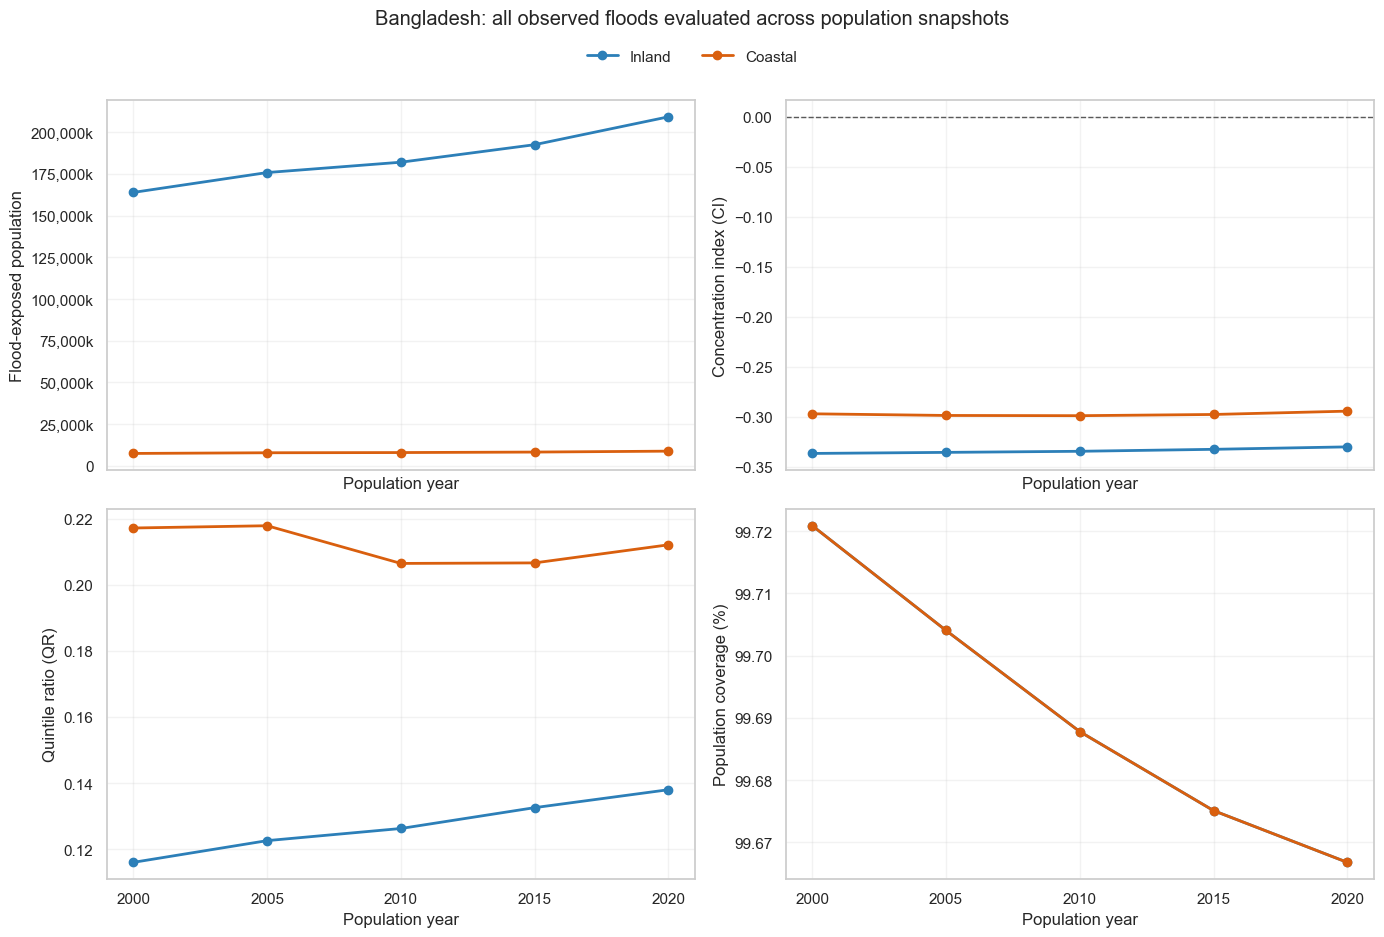

In [83]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
plot_specs = [
    ("Total Flood Risk", "Flood-exposed population", axes[0, 0]),
    ("CI", "Concentration index (CI)", axes[0, 1]),
    ("QR", "Quintile ratio (QR)", axes[1, 0]),
    ("Population Coverage (%)", "Population coverage (%)", axes[1, 1]),
]

for metric, ylabel, ax in plot_specs:
    for flood_type in FLOOD_TYPES:
        subset = all_years.loc[all_years["flood_type"].eq(flood_type)]
        ax.plot(
            subset["population_year"], subset[metric], marker="o", linewidth=2,
            label=FLOOD_TYPE_LABELS[flood_type], color=FLOOD_TYPE_COLORS[flood_type],
        )
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Population year")
    ax.set_xticks(sorted(expected_snapshot_years))
    if metric == "Total Flood Risk":
        ax.yaxis.set_major_formatter(FuncFormatter(thousands))
    if metric == "CI":
        ax.axhline(0, color="0.35", linewidth=1, linestyle="--")
    ax.grid(alpha=0.25)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.01))
fig.suptitle(f"{COUNTRY_NAME}: all observed floods evaluated across population snapshots", y=1.04)
fig.tight_layout()
plt.show()

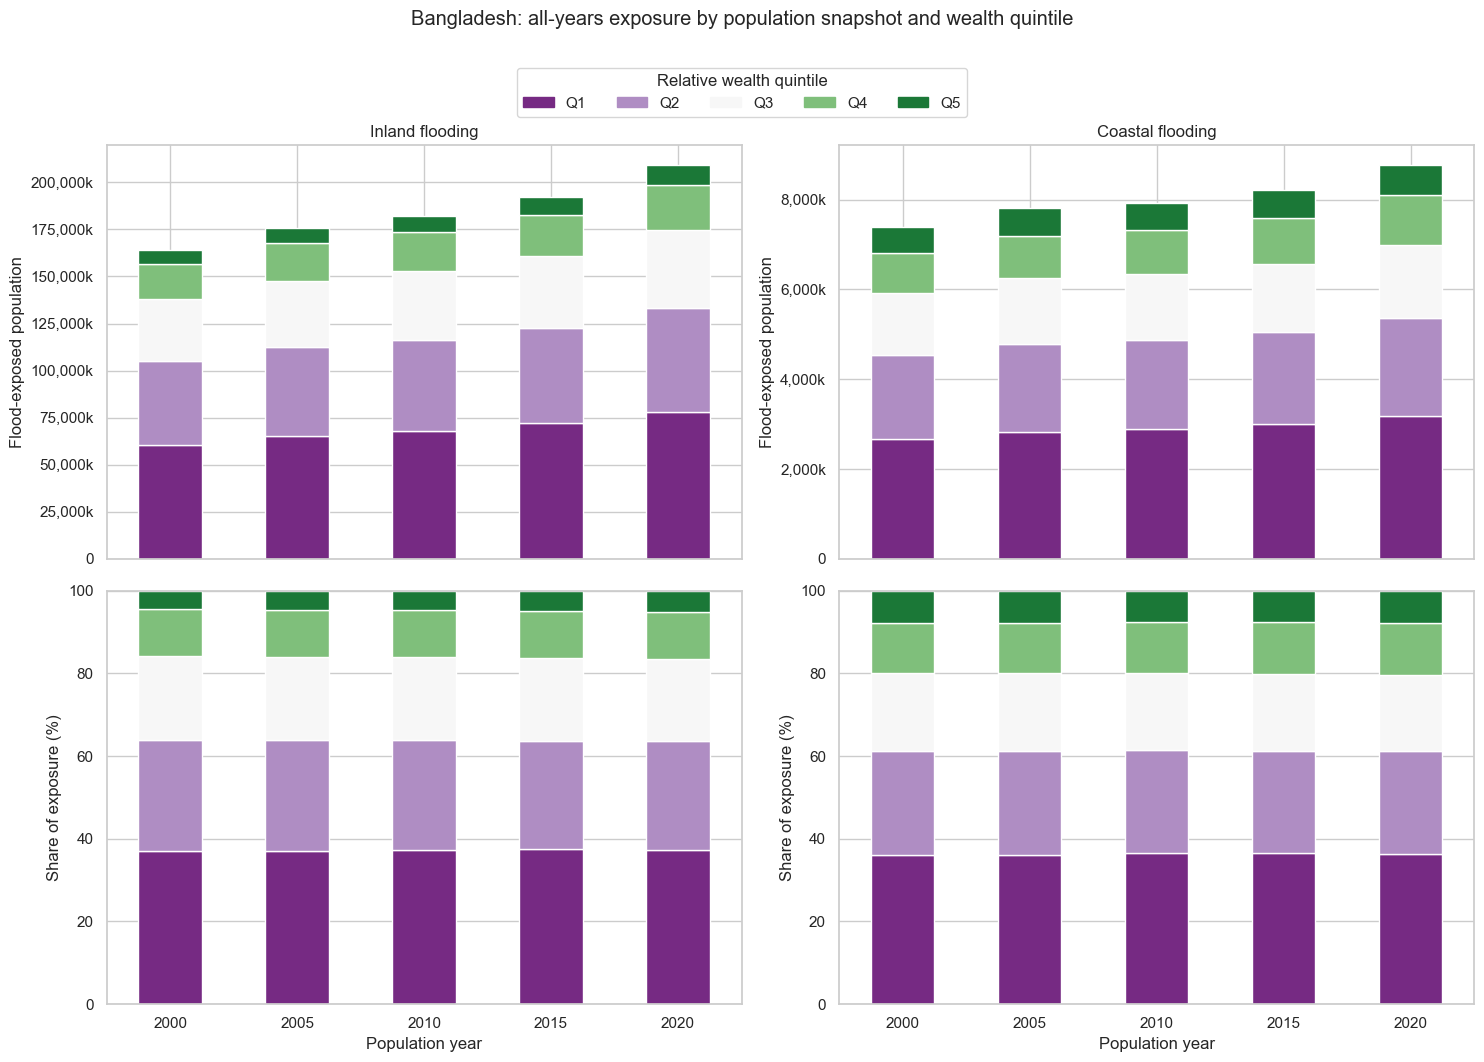

In [84]:
all_years_quintiles = all_years.melt(
    id_vars=["population_year", "flood_type", "flood_type_label", "Total Flood Risk"],
    value_vars=QUINTILE_COLUMNS,
    var_name="wealth_quintile",
    value_name="flood_exposure",
)
all_years_quintiles["wealth_quintile"] = all_years_quintiles["wealth_quintile"].map(QUINTILE_LABELS)
all_years_quintiles["exposure_share_percent"] = np.where(
    all_years_quintiles["Total Flood Risk"].gt(0),
    all_years_quintiles["flood_exposure"] / all_years_quintiles["Total Flood Risk"] * 100,
    np.nan,
)

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex="col")
for column_index, flood_type in enumerate(FLOOD_TYPES):
    subset = all_years_quintiles.loc[all_years_quintiles["flood_type"].eq(flood_type)]
    exposure_pivot = (
        subset.pivot(index="population_year", columns="wealth_quintile", values="flood_exposure")
        .reindex(columns=[f"Q{i}" for i in range(1, 6)])
        .fillna(0)
    )
    share_pivot = (
        subset.pivot(index="population_year", columns="wealth_quintile", values="exposure_share_percent")
        .reindex(columns=[f"Q{i}" for i in range(1, 6)])
    )

    if exposure_pivot.to_numpy().sum() > 0:
        exposure_pivot.plot(kind="bar", stacked=True, ax=axes[0, column_index], color=QUINTILE_COLORS, legend=False)
        share_pivot.plot(kind="bar", stacked=True, ax=axes[1, column_index], color=QUINTILE_COLORS, legend=False)
    else:
        for ax in axes[:, column_index]:
            ax.text(0.5, 0.5, "No recorded exposure", ha="center", va="center", transform=ax.transAxes)
            ax.set_xticks(range(len(expected_snapshot_years)))
            ax.set_xticklabels(sorted(expected_snapshot_years))

    axes[0, column_index].set_title(f"{FLOOD_TYPE_LABELS[flood_type]} flooding")
    axes[0, column_index].set_ylabel("Flood-exposed population")
    axes[0, column_index].yaxis.set_major_formatter(FuncFormatter(thousands))
    axes[1, column_index].set_ylabel("Share of exposure (%)")
    axes[1, column_index].set_ylim(0, 100)
    axes[1, column_index].set_xlabel("Population year")
    axes[0, column_index].set_xlabel("")
    for ax in axes[:, column_index]:
        ax.tick_params(axis="x", rotation=0)

handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in QUINTILE_COLORS]
fig.legend(handles, [f"Q{i}" for i in range(1, 6)], title="Relative wealth quintile", ncol=5, loc="upper center", bbox_to_anchor=(0.5, 1.01))
fig.suptitle(f"{COUNTRY_NAME}: all-years exposure by population snapshot and wealth quintile", y=1.06)
fig.tight_layout()
plt.show()

## 7. Compact exploratory findings table

This final table collects descriptive changes only. It does not estimate trends, uncertainty, or statistical significance.

In [85]:
finding_records = []
for flood_type in FLOOD_TYPES:
    label = FLOOD_TYPE_LABELS[flood_type]
    annual_subset = annual_current.loc[annual_current["flood_type"].eq(flood_type)]
    snapshot_subset = all_years.loc[all_years["flood_type"].eq(flood_type)].set_index("population_year")
    positive_annual = annual_subset.loc[annual_subset["has_exposure"]]

    if positive_annual.empty:
        peak_year = pd.NA
        peak_exposure = 0.0
    else:
        peak_index = positive_annual["Total Flood Risk"].idxmax()
        peak_year = int(positive_annual.loc[peak_index, "flood_year"])
        peak_exposure = positive_annual.loc[peak_index, "Total Flood Risk"]

    exposure_2000 = snapshot_subset.loc[2000, "Total Flood Risk"]
    exposure_2020 = snapshot_subset.loc[2020, "Total Flood Risk"]
    finding_records.append(
        {
            "flood_type": label,
            "annual_years_with_exposure": int(annual_subset["has_exposure"].sum()),
            "peak_annual_exposure_year": peak_year,
            "peak_annual_exposure": peak_exposure,
            "all_floods_exposure_2000": exposure_2000,
            "all_floods_exposure_2020": exposure_2020,
            "all_floods_exposure_change_percent": (
                (exposure_2020 / exposure_2000 - 1) * 100 if exposure_2000 != 0 else np.nan
            ),
            "all_floods_CI_2000": snapshot_subset.loc[2000, "CI"],
            "all_floods_CI_2020": snapshot_subset.loc[2020, "CI"],
            "all_floods_QR_2000": snapshot_subset.loc[2000, "QR"],
            "all_floods_QR_2020": snapshot_subset.loc[2020, "QR"],
        }
    )

exploratory_findings = pd.DataFrame(finding_records).set_index("flood_type")
display(exploratory_findings)

,annual_years_with_exposure,peak_annual_exposure_year,peak_annual_exposure,all_floods_exposure_2000,all_floods_exposure_2020,all_floods_exposure_change_percent,all_floods_CI_2000,all_floods_CI_2020,all_floods_QR_2000,all_floods_QR_2020
flood_type,,,,,,,,,,
Inland,19,2007,"59,976,278.597","163,859,315.452","209,155,913.477",27.644,-0.337,-0.330,0.116,0.138
Coastal,4,2010,"4,171,882.596","7,395,473.627","8,766,546.511",18.539,-0.297,-0.295,0.217,0.212


## 8. Notes for later multi-country scaling

- `load_country_results()` already accepts a country-specific directory and keeps filename-derived dimensions explicit.
- A multi-country version can iterate over ISO3 directories, add an `iso3` column, and concatenate the returned tables.
- Before cross-country inference, define minimum exposure and population-coverage criteria, and decide how zero-exposure cases should enter summaries.
- Annual observations are not necessarily independent events, and annual CI/QR can be unstable when exposed population is small. Exposure thresholds and uncertainty should therefore accompany later trend analyses.
- Inland and coastal inequality metrics should remain separate until a combined flood footprint is processed upstream and CI/QR are recalculated from the underlying population–wealth–exposure distribution.